In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import random
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import torch

# Add src to path
sys.path.append(os.path.abspath(".."))

from tqdm.notebook import tqdm

import src.optimize_2d as opt2d
import src.vis_2d as vis2d
from src.loss_2d import BiGaussianLoss
from src.props_2d import OptimizationProps, SamplingProps, TemplateProps

In [3]:
# 1. Load Data
data_path = Path("../data/2d_training_data.pkl")
if not data_path.exists():
    print(f"Data file {data_path} not found. Please run src/generate_2d_data.py first.")
else:
    print(f"Loading data from {data_path}...")
    data = joblib.load(data_path)
    image_np = -data["image"]
    contour_np = data["contour"]
    gt_contour_np = data["gt"]

Loading data from ../data/2d_training_data.pkl...


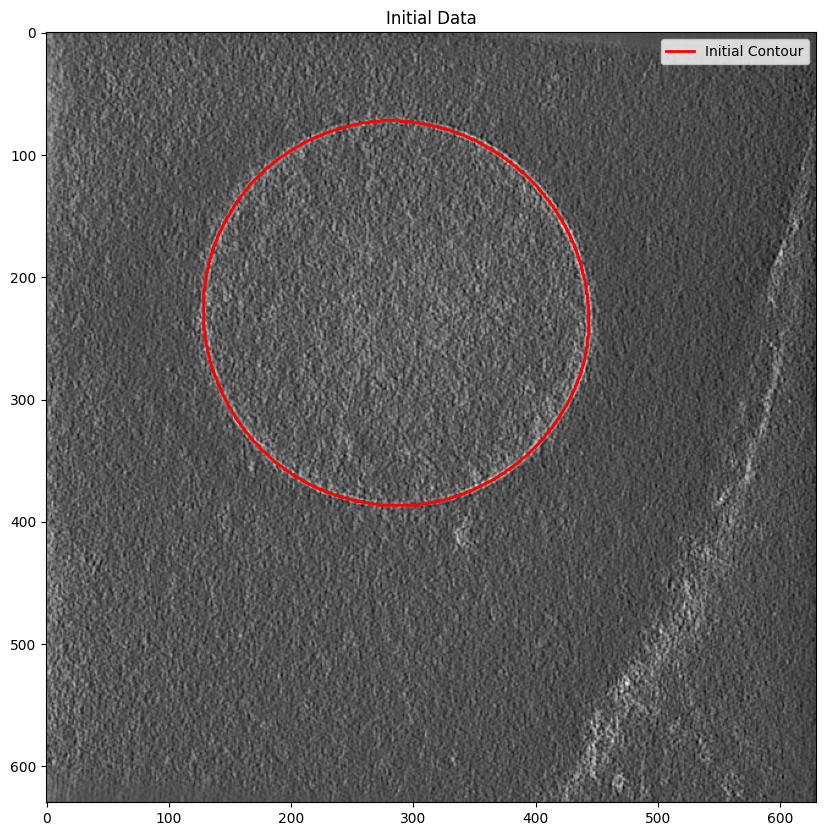

In [4]:
# Visualize Initial Data
plt.figure(figsize=(10, 10))
plt.imshow(image_np, cmap="gray")
plt.plot(contour_np[:, 1], contour_np[:, 0], "r-", linewidth=2, label="Initial Contour")
if len(gt_contour_np) > 0:
    plt.plot(gt_contour_np[:, 1], gt_contour_np[:, 0], "g--", linewidth=2, label="Ground Truth")
plt.legend()
plt.title("Initial Data")
plt.show()

Smoothing initial contour...


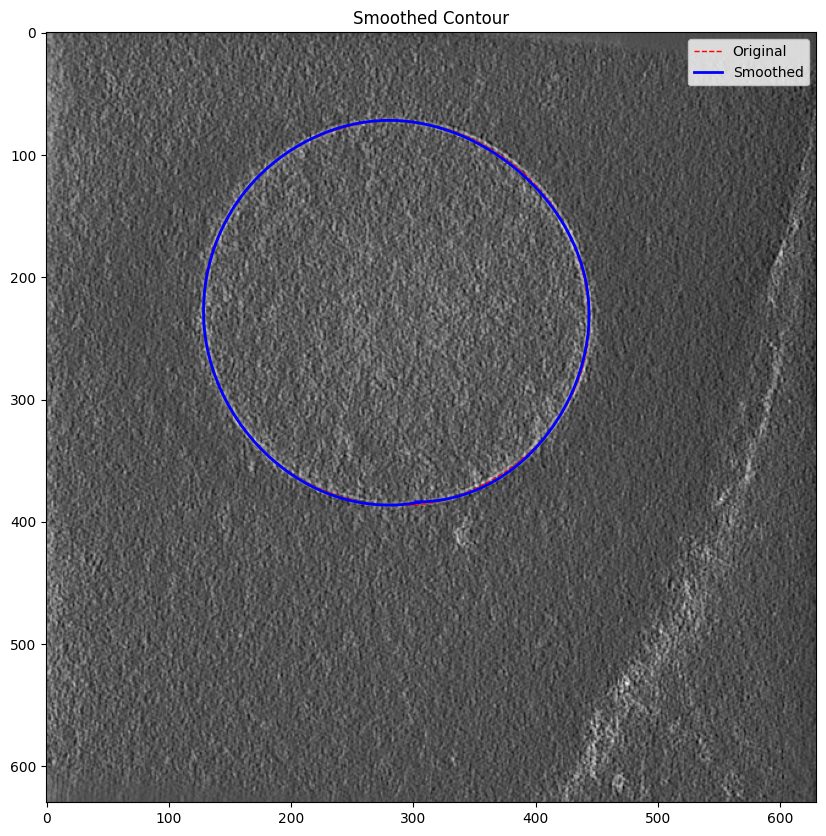

In [5]:
# 2. Smooth Contour
print("Smoothing initial contour...")
contour_smoothed, spline = opt2d.smooth_contour(contour_np, num_points=1024, return_spline=True)

plt.figure(figsize=(10, 10))
plt.imshow(image_np, cmap="gray")
plt.plot(contour_np[:, 1], contour_np[:, 0], "r--", linewidth=1, label="Original")
plt.plot(contour_smoothed[:, 1], contour_smoothed[:, 0], "b-", linewidth=2, label="Smoothed")
plt.legend()
plt.title("Smoothed Contour")
plt.show()

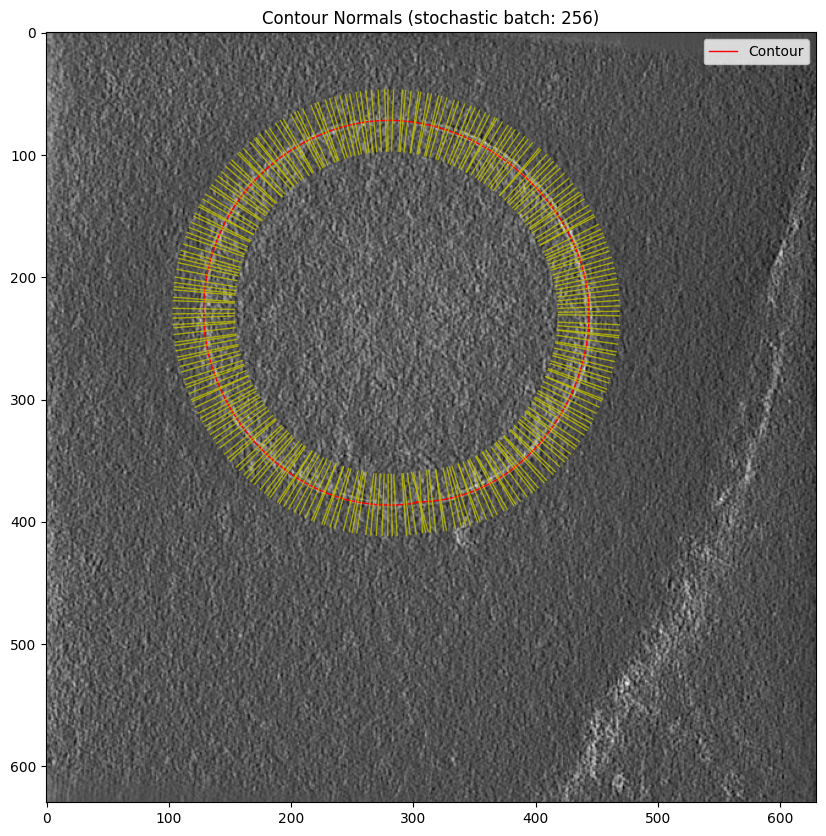

In [6]:
sampling_props = SamplingProps(num_samples=51, sample_step=1.0, width=3, batch_size=256)
template_props = TemplateProps(peak_dist=4.5, width=0.5, num_samples=51)
optimization_props = OptimizationProps()

vis2d.plot_contour_normals(
    image_np, contour_smoothed, sampling_props=sampling_props, stochastic=True
)

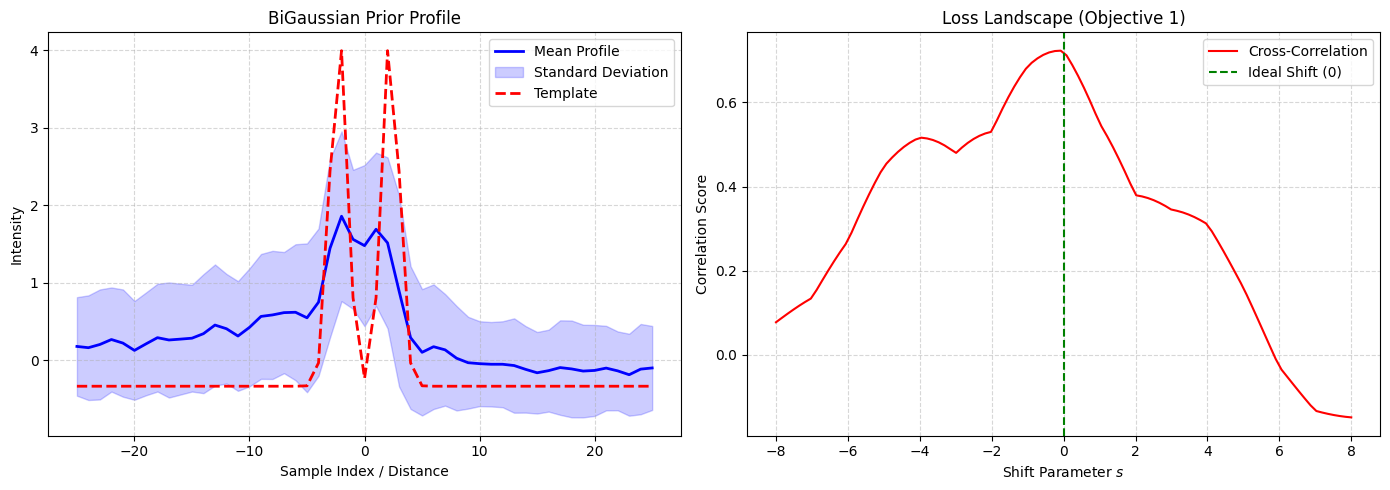

In [7]:
vis2d.plot_prior_and_landscape_from_contour(
    image_np,
    contour_smoothed,
    sampling_props=sampling_props,
    template_props=template_props,
)

In [8]:
template_props.num_samples

51

In [9]:
### TESTING THE CONTOUR REFINER ###

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

refiner = opt2d.ContourRefiner(
    image=image_np,
    initial_contour=contour_smoothed,
    optimization_props=OptimizationProps(w_edge=10, w_laplacian=20, lr=0.1),
    template_props=template_props,
    sampling_props=sampling_props,
    laplacian_window_size=5,
)
refiner.to(device)
print(f"Refiner initialized on {device}")

Refiner initialized on cuda


In [31]:
num_iterations = 500
history = []

print("Starting optimization...")
for i in tqdm(range(num_iterations)):
    # 1. Optimization Step
    metrics = refiner.step()
    history.append(metrics)


print("Optimization finished.")

Starting optimization...


  0%|          | 0/500 [00:00<?, ?it/s]

Optimization finished.


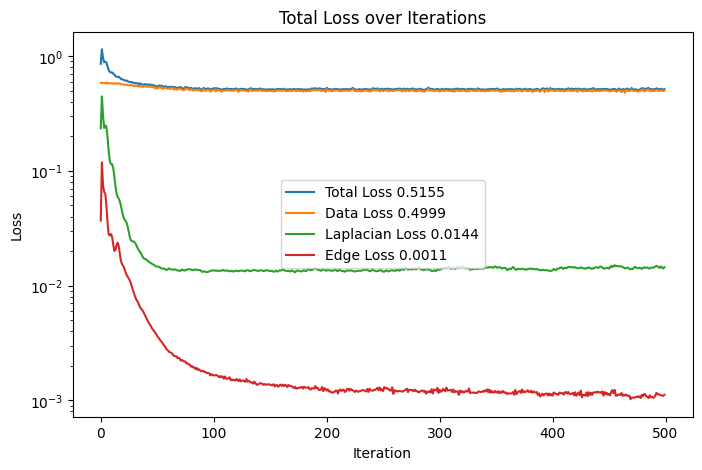

In [32]:
total_losses = [h["total_loss"] for h in history]
data_losses = [h["data_loss"] for h in history]
laplacian_losses = [h["laplacian_loss"] for h in history]
edge_losses = [h["edge_loss"] for h in history]
plt.figure(figsize=(8, 5))
plt.plot(total_losses, label=f"Total Loss {total_losses[-1]:.4f}")
plt.plot(data_losses, label=f"Data Loss {data_losses[-1]:.4f}")
plt.plot(laplacian_losses, label=f"Laplacian Loss {laplacian_losses[-1]:.4f}")
plt.plot(edge_losses, label=f"Edge Loss {edge_losses[-1]:.4f}")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Total Loss over Iterations")
plt.legend()
plt.show()

(20,)


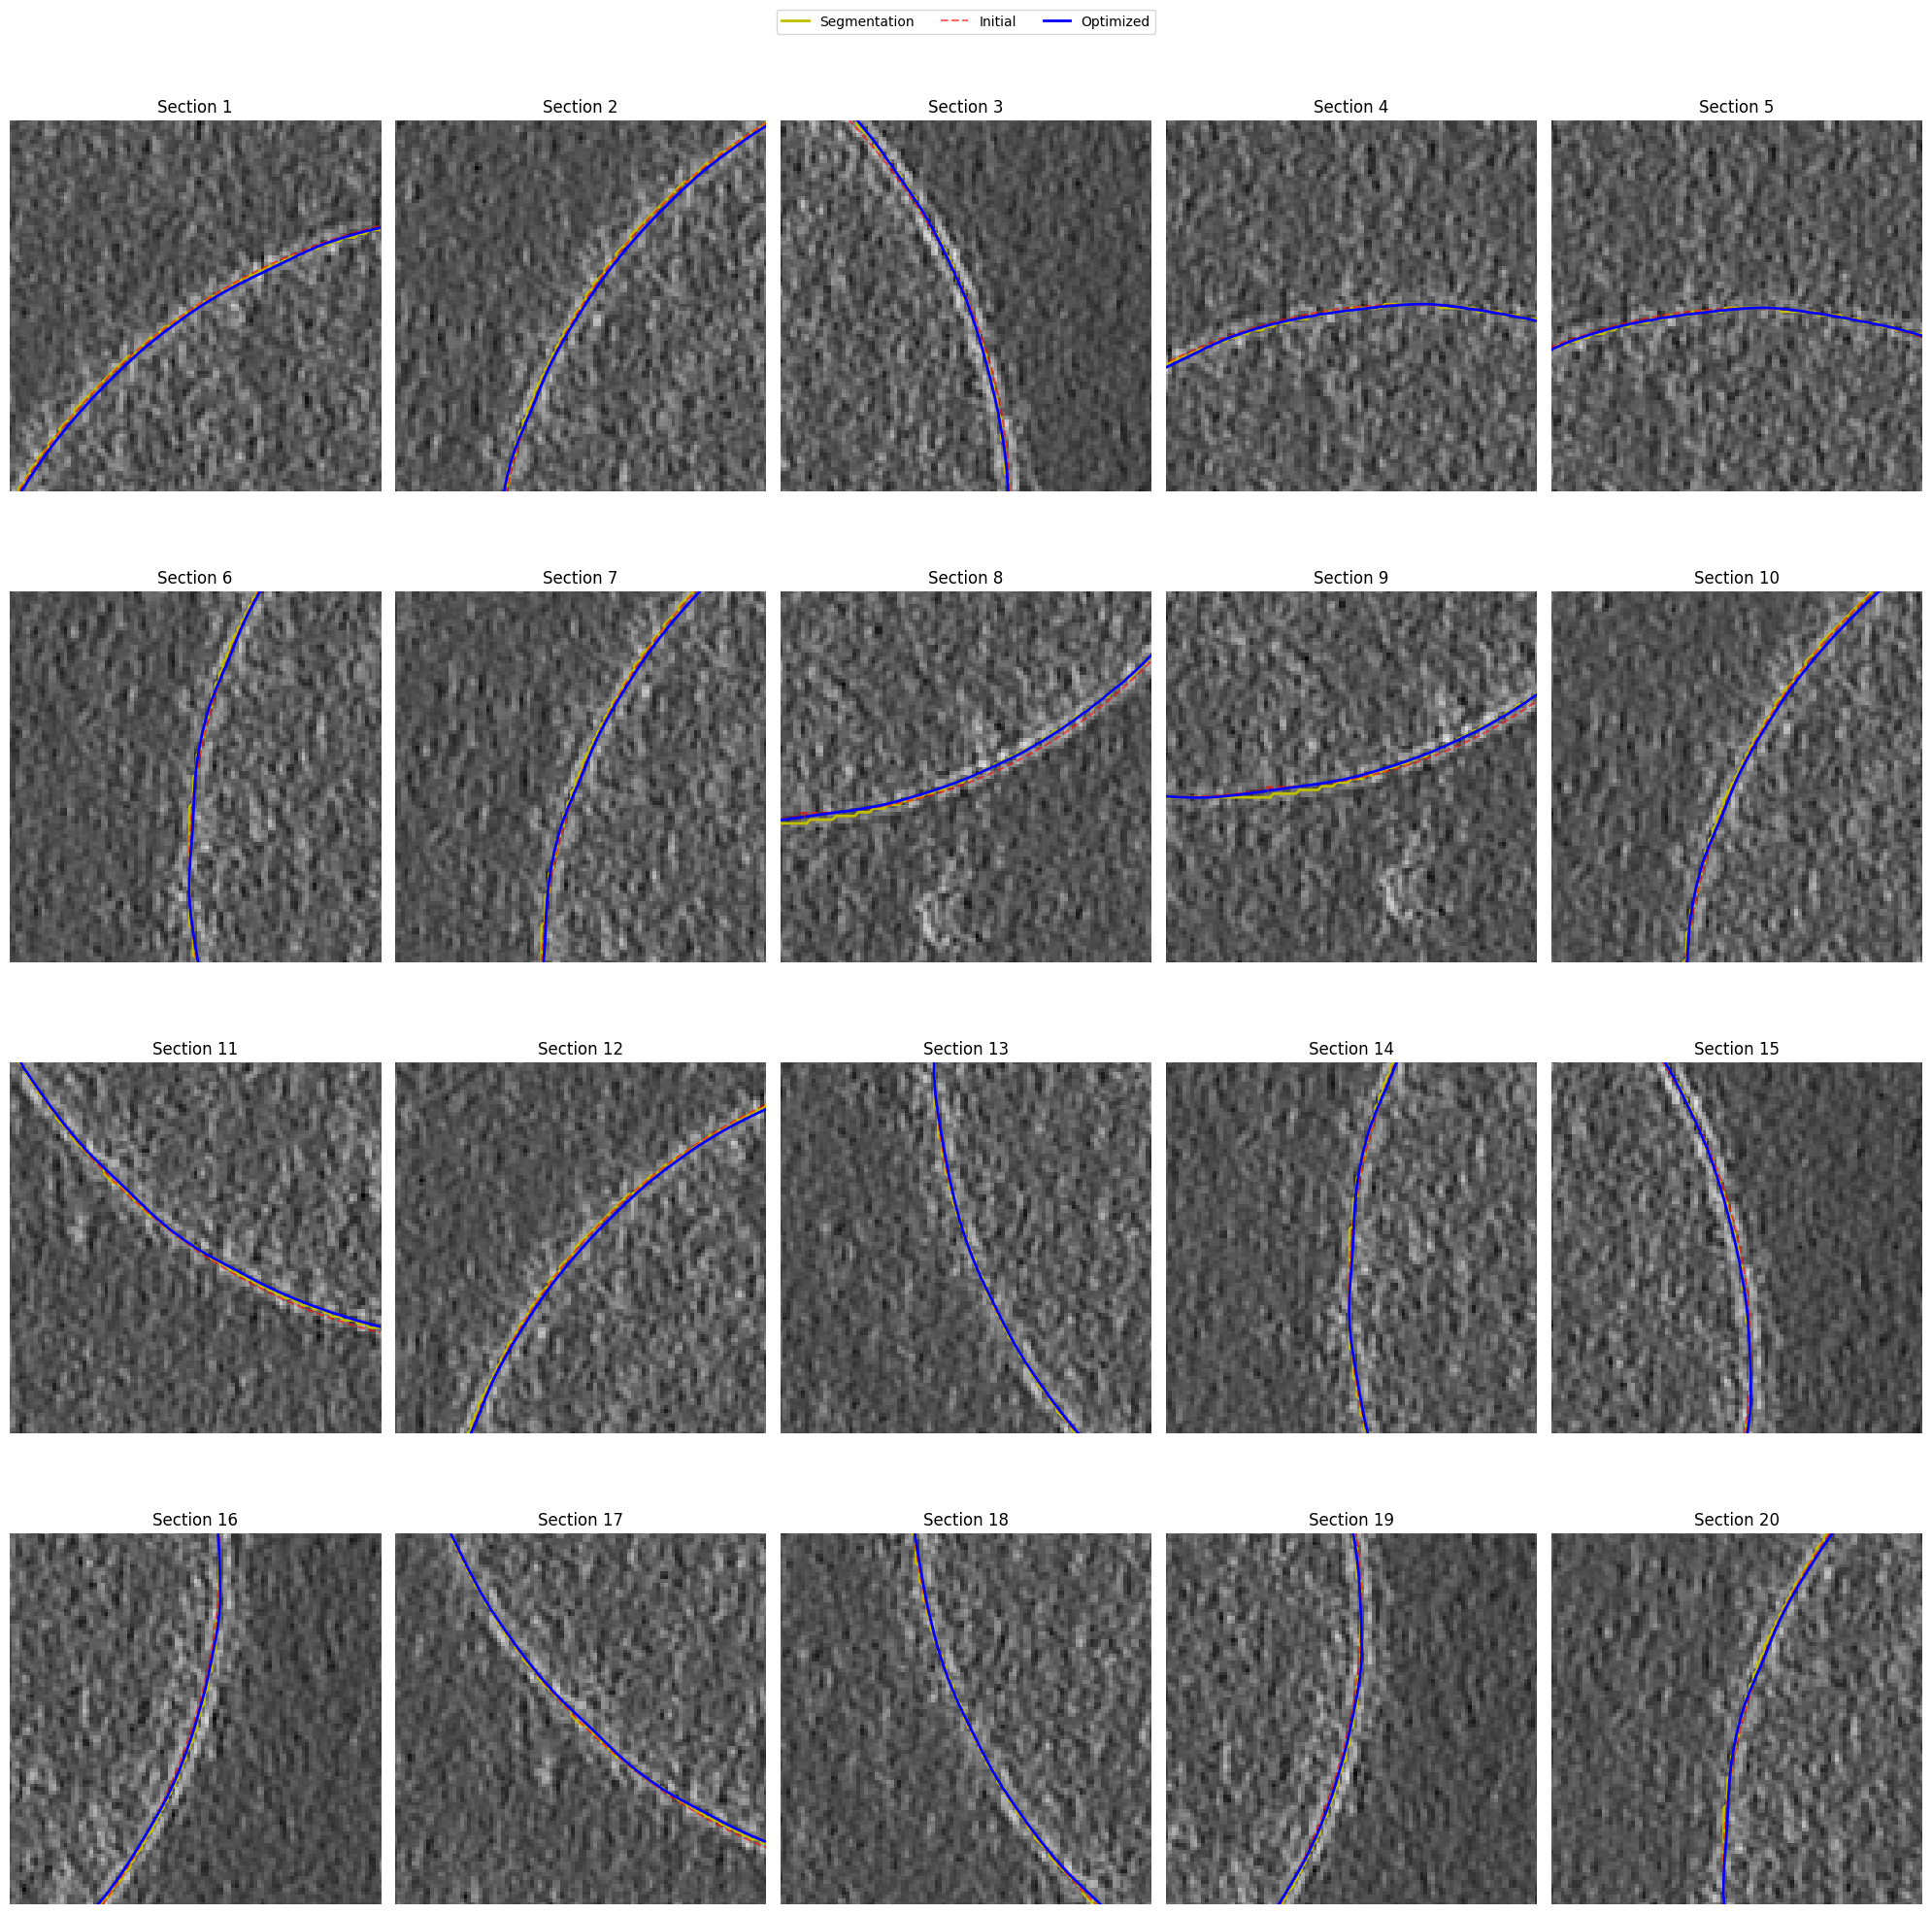

In [33]:
init_contour = contour_smoothed

num_crops = 20
crop_size = 100
half_size = crop_size // 2

# Ensure we have the final contour on CPU
final_contour = refiner.contour.detach().cpu().numpy()

# Select random indices along the final contour to center our crops
# We use the final contour to ensure we look at relevant areas
indices = random.sample(range(len(final_contour)), num_crops)

cols = 5
rows = np.ceil(num_crops / cols).astype(int)
fig, axes = plt.subplots(rows, cols, figsize=(20, 20))
axes = axes.flatten()
# if num_crops == 1:
#    axes = [axes]
print(axes.shape)
H, W = image_np.shape

for i, idx in enumerate(indices):
    ax = axes[i]

    # Center of the crop (row, col) -> (y, x)
    cy, cx = final_contour[idx]

    # Define bounds (handling image edges)
    y_min = max(0, int(cy - half_size))
    y_max = min(H, int(cy + half_size))
    x_min = max(0, int(cx - half_size))
    x_max = min(W, int(cx + half_size))

    # Display the image
    ax.imshow(image_np, cmap="gray")

    # Plot contours
    # Note: plot takes (x, y) which corresponds to (col, row)
    ax.plot(contour_np[:, 1], contour_np[:, 0], "y-", linewidth=2, label="Segmentation")
    ax.plot(
        init_contour[:, 1], init_contour[:, 0], "r--", alpha=0.6, linewidth=1.5, label="Initial"
    )
    ax.plot(final_contour[:, 1], final_contour[:, 0], "b-", linewidth=2, label="Optimized")

    if "gt_contour_np" in locals() and len(gt_contour_np) > 0:
        ax.plot(gt_contour_np[:, 1], gt_contour_np[:, 0], "g:", alpha=0.8, linewidth=2, label="GT")

    # Zoom in by setting axis limits
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_max, y_min)  # Invert Y axis to match image origin (top-left)

    ax.set_title(f"Section {i + 1}")
    ax.axis("off")

# Add a single legend for the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.show()

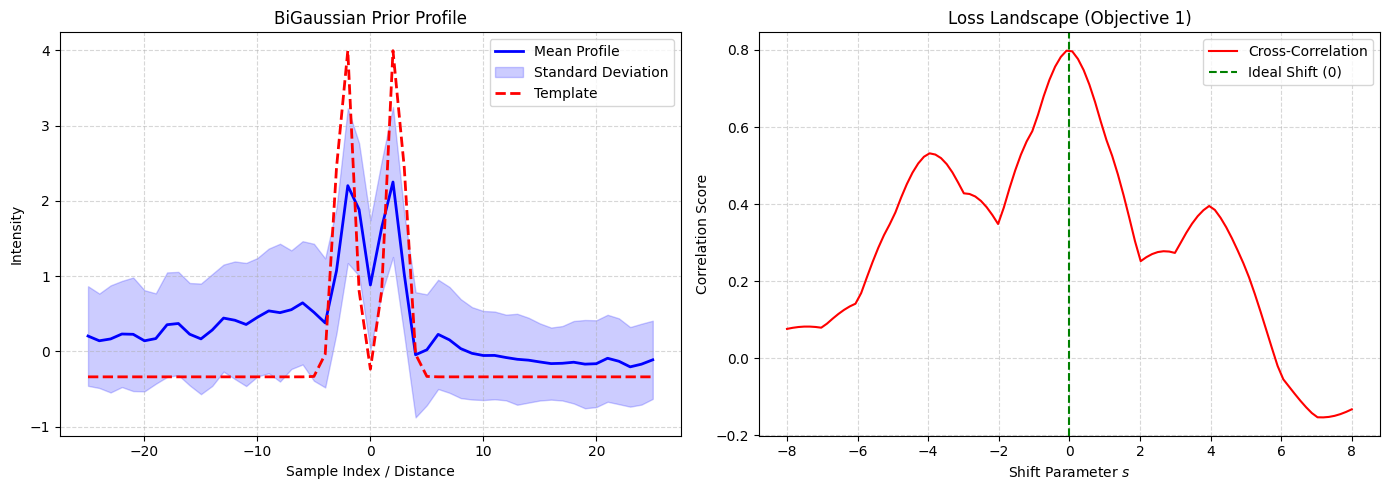

In [34]:
vis2d.plot_prior_and_landscape_from_contour(
    image_np,
    final_contour,
    sampling_props=sampling_props,
    template_props=template_props,
)

In [35]:
### TESTING THE BSPLINE REFINER ###

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

refiner = opt2d.BSplineContourRefiner(
    image=image_np,
    initial_contour=contour_smoothed,
    optimization_props=OptimizationProps(w_edge=10, w_laplacian=0.01, lr=0.1),
    template_props=template_props,
    sampling_props=sampling_props,
    laplacian_window_size=1,
    num_eval_points=500,
)
refiner.to(device)
print(f"Refiner initialized on {device}")

Refiner initialized on cuda


In [37]:
num_iterations = 500
history = []

print("Starting optimization...")
for i in tqdm(range(num_iterations)):
    # 1. Optimization Step
    metrics = refiner.step()
    history.append(metrics)


print("Optimization finished.")

Starting optimization...


  0%|          | 0/500 [00:00<?, ?it/s]

Optimization finished.


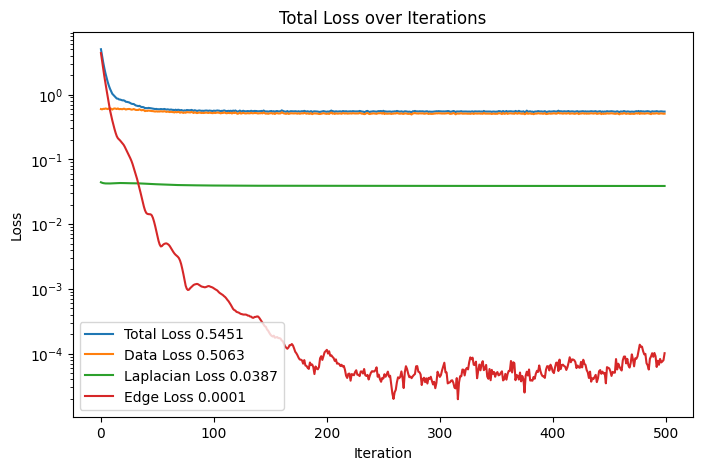

In [38]:
total_losses = [h["total_loss"] for h in history]
data_losses = [h["data_loss"] for h in history]
laplacian_losses = [h["laplacian_loss"] for h in history]
edge_losses = [h["edge_loss"] for h in history]
plt.figure(figsize=(8, 5))
plt.plot(total_losses, label=f"Total Loss {total_losses[-1]:.4f}")
plt.plot(data_losses, label=f"Data Loss {data_losses[-1]:.4f}")
plt.plot(laplacian_losses, label=f"Laplacian Loss {laplacian_losses[-1]:.4f}")
plt.plot(edge_losses, label=f"Edge Loss {edge_losses[-1]:.4f}")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Total Loss over Iterations")
plt.legend()
plt.show()

(20,)


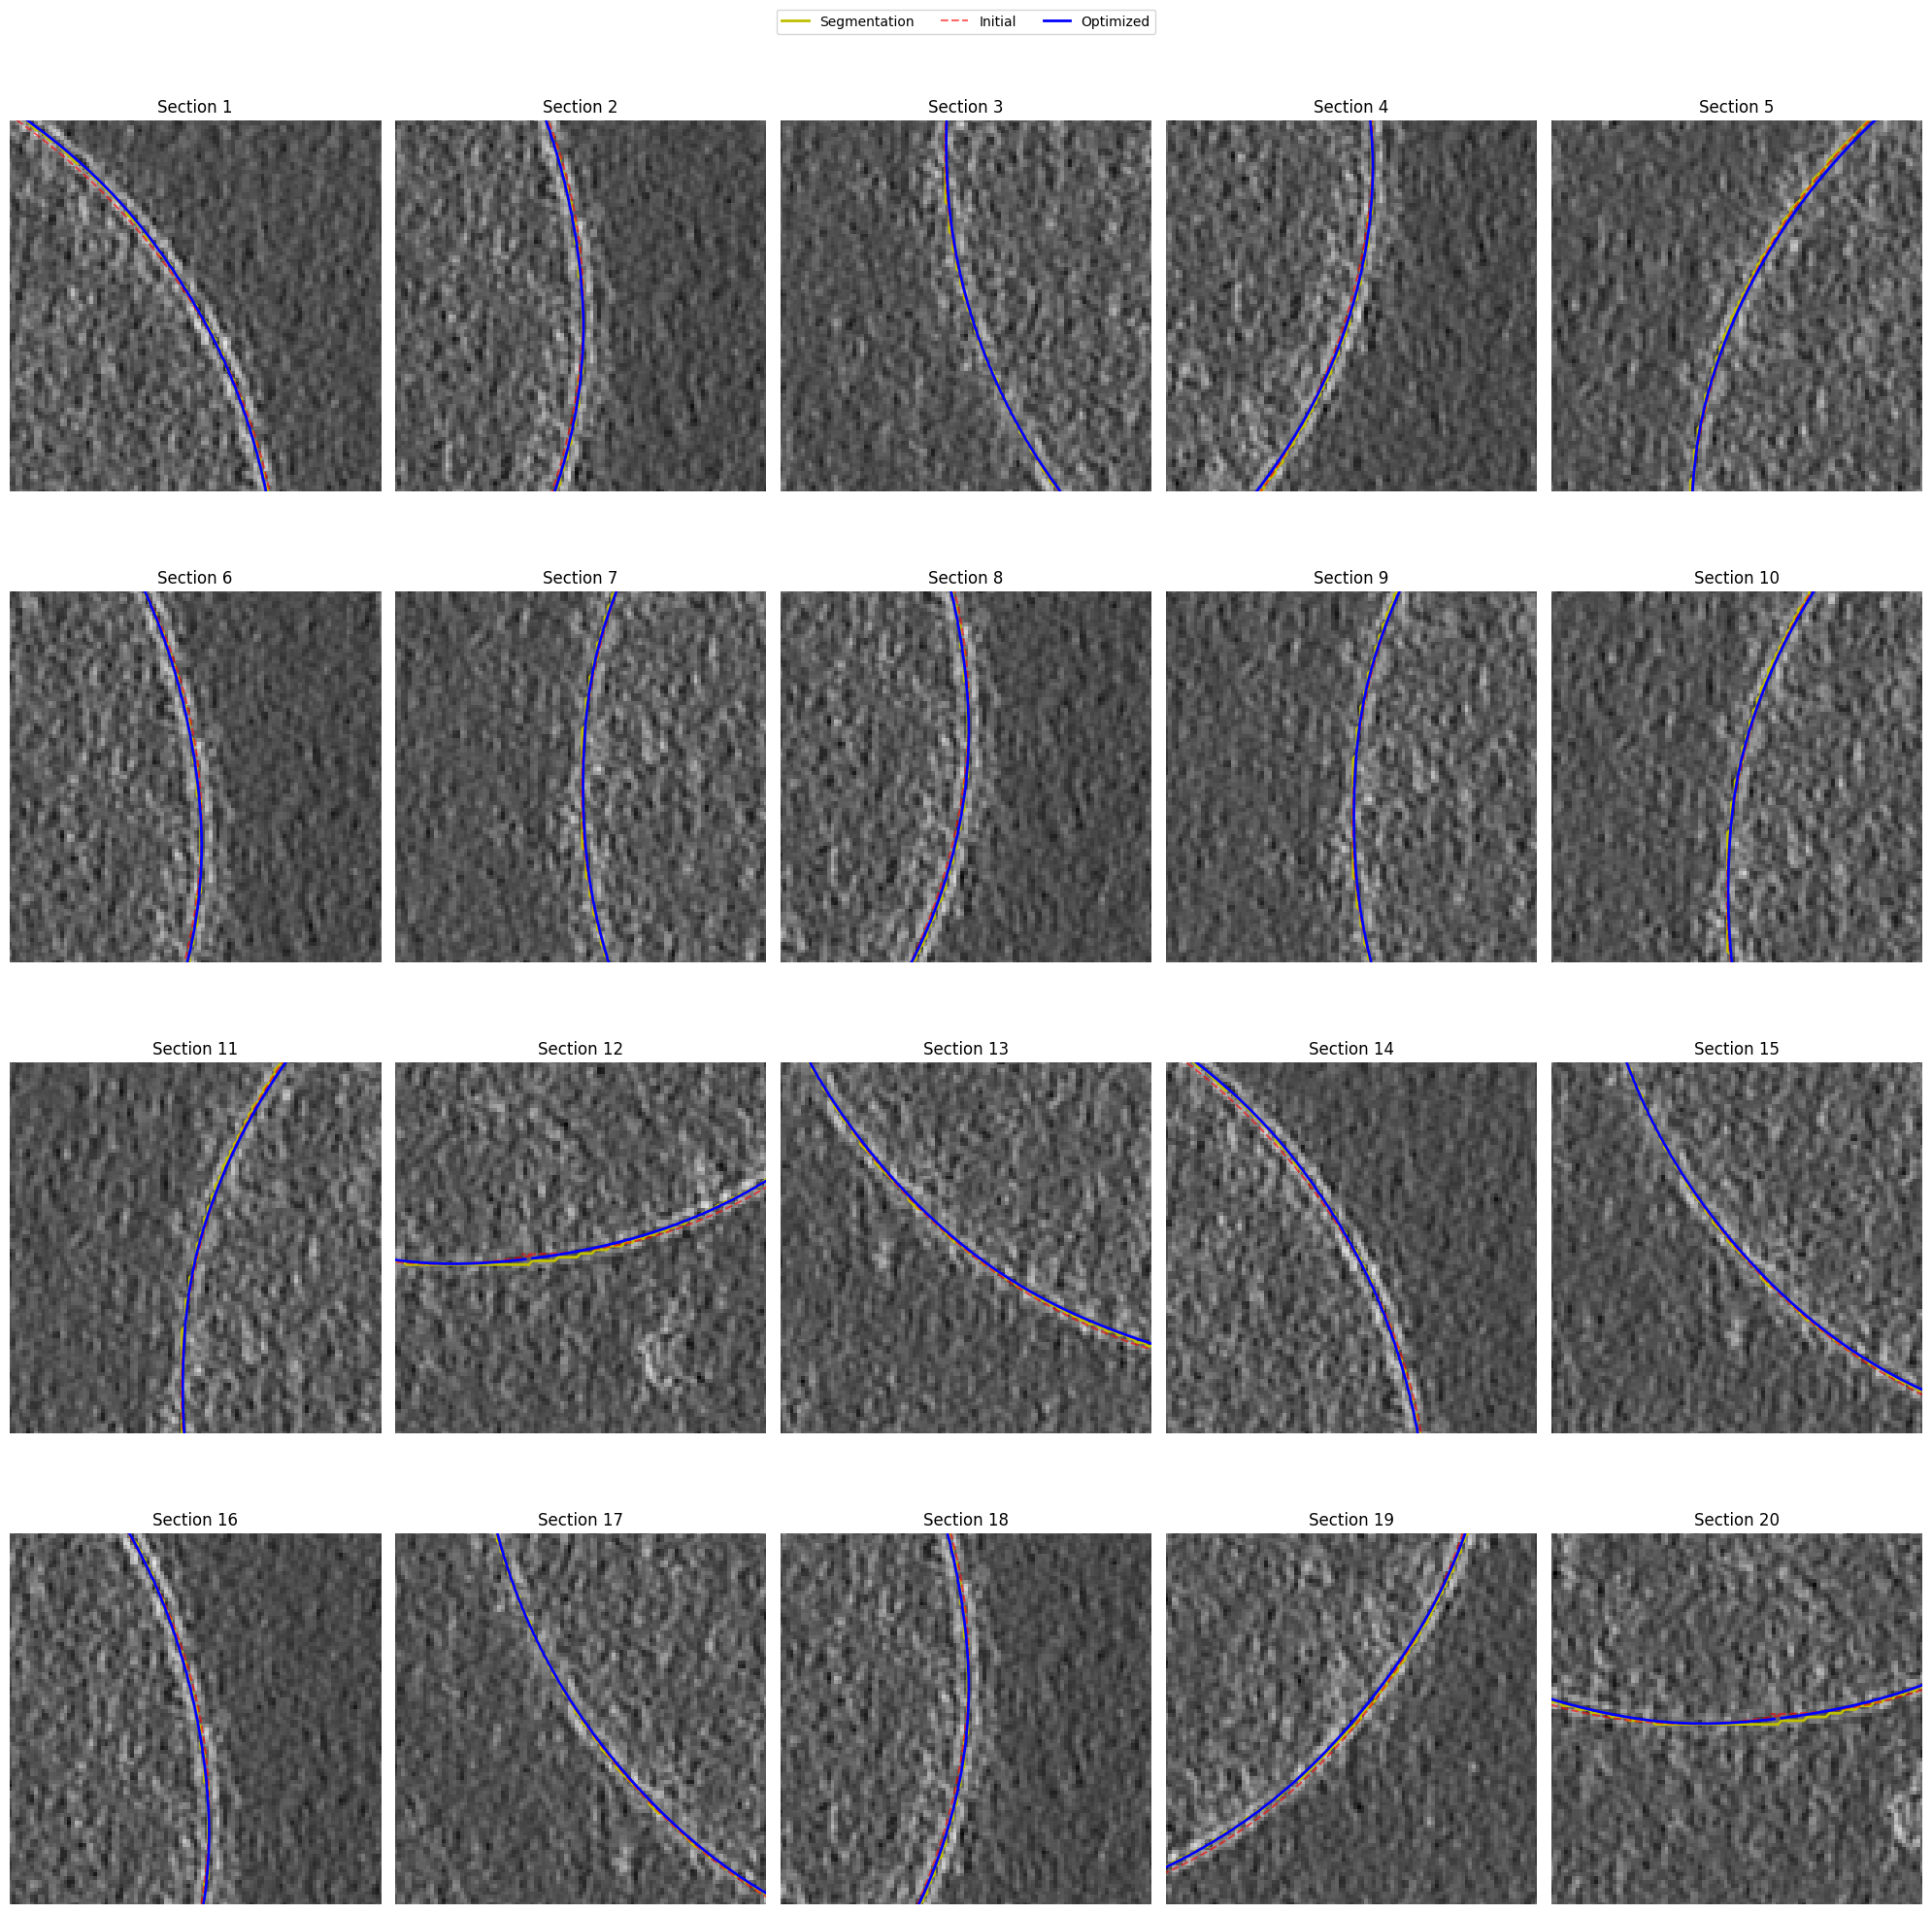

In [39]:
init_contour = contour_smoothed

num_crops = 20
crop_size = 100
half_size = crop_size // 2

# Ensure we have the final contour on CPU
final_contour = refiner.contour.detach().cpu().numpy()

# Select random indices along the final contour to center our crops
# We use the final contour to ensure we look at relevant areas
indices = random.sample(range(len(final_contour)), num_crops)

cols = 5
rows = np.ceil(num_crops / cols).astype(int)
fig, axes = plt.subplots(rows, cols, figsize=(20, 20))
axes = axes.flatten()
# if num_crops == 1:
#    axes = [axes]
print(axes.shape)
H, W = image_np.shape

for i, idx in enumerate(indices):
    ax = axes[i]

    # Center of the crop (row, col) -> (y, x)
    cy, cx = final_contour[idx]

    # Define bounds (handling image edges)
    y_min = max(0, int(cy - half_size))
    y_max = min(H, int(cy + half_size))
    x_min = max(0, int(cx - half_size))
    x_max = min(W, int(cx + half_size))

    # Display the image
    ax.imshow(image_np, cmap="gray")

    # Plot contours
    # Note: plot takes (x, y) which corresponds to (col, row)
    ax.plot(contour_np[:, 1], contour_np[:, 0], "y-", linewidth=2, label="Segmentation")
    ax.plot(
        init_contour[:, 1], init_contour[:, 0], "r--", alpha=0.6, linewidth=1.5, label="Initial"
    )
    ax.plot(final_contour[:, 1], final_contour[:, 0], "b-", linewidth=2, label="Optimized")

    if "gt_contour_np" in locals() and len(gt_contour_np) > 0:
        ax.plot(gt_contour_np[:, 1], gt_contour_np[:, 0], "g:", alpha=0.8, linewidth=2, label="GT")

    # Zoom in by setting axis limits
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_max, y_min)  # Invert Y axis to match image origin (top-left)

    ax.set_title(f"Section {i + 1}")
    ax.axis("off")

# Add a single legend for the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.show()

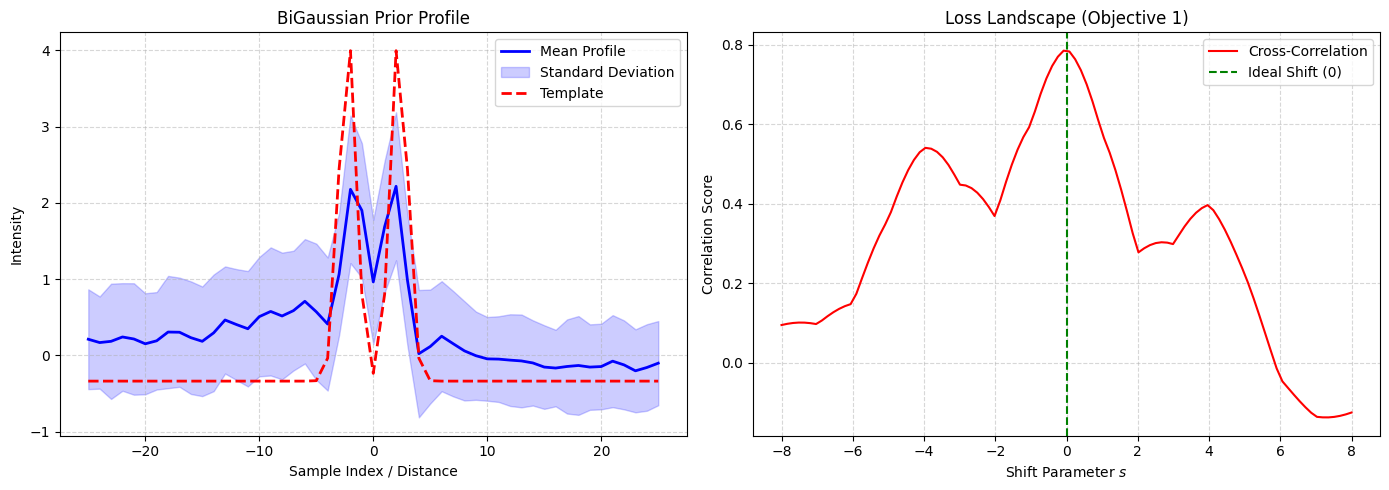

In [40]:
vis2d.plot_prior_and_landscape_from_contour(
    image_np,
    final_contour,
    sampling_props=sampling_props,
    template_props=template_props,
)